<a href="https://colab.research.google.com/github/arukhsarh/DH_Intership_Tasks/blob/main/Task2_Credit_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

url = "https://raw.githubusercontent.com/subashgandyer/datasets/main/loan_prediction.csv"
df = pd.read_csv(url)

if 'Loan_ID' in df.columns:
    df = df.drop('Loan_ID', axis=1)

print("Data load!")
df.head()

Data load!


,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
0,1,0,0,0,0,2,1,5849.0,0.0,146.412162,360.0,1.0
1,1,1,1,0,0,0,0,4583.0,1508.0,128.000000,360.0,1.0
2,1,1,0,0,1,2,1,3000.0,0.0,66.000000,360.0,1.0
3,1,1,0,1,0,2,1,2583.0,2358.0,120.000000,360.0,1.0
4,1,0,0,0,0,2,1,6000.0,0.0,141.000000,360.0,1.0


In [5]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model's accuracy: {accuracy * 100:.2f}%")
print("-" * 35)
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Model's accuracy: 78.86%
-----------------------------------
Confusion Matrix:
[[18 25]
 [ 1 79]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


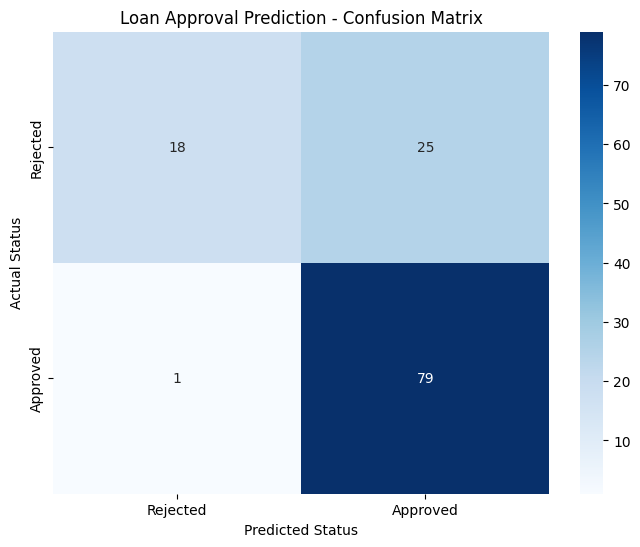

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])

plt.xlabel('Predicted Status')
plt.ylabel('Actual Status')
plt.title('Loan Approval Prediction - Confusion Matrix')
plt.show()